In [1]:
#Initialization 1 (nothing new here)

import os

import pandas as pd
import numpy as np
from sklearn.cluster import SpectralClustering, KMeans, AgglomerativeClustering
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
from dtaidistance import dtw
from scipy.signal import find_peaks
from pywt import wavedec
from sklearn.metrics import adjusted_rand_score, jaccard_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
#Initialization 2 (nothing new here)
EPS = 1e-12

random_gen = np.random.RandomState(0)

sample_dir = "samples"
sesdyn_data_path = os.path.join("BehaviorDatasets", "SESDYN_Basic_A",
                                sample_dir, "Basic_A_Complete.xlsx")
sesdyn_df = pd.read_excel(sesdyn_data_path)
sesdyn_df = sesdyn_df.rename(columns={"Final": 100})

sesdyn_df = sesdyn_df[~sesdyn_df["Label"].isin(["GR1D2", "GR1D3"])]

full_df = sesdyn_df.drop(["Instance No", "Batch", "ID", "Simulation"], axis=1)
freq_col_arr = full_df.iloc[:, 1:].columns.values

full_df

,Label,0,0.25,0.5,0.75,1,1.25,1.5,1.75,2,...,97.75,98,98.25,98.5,98.75,99,99.25,99.5,99.75,100
0,GR2D3,104.832000,114.654000,124.899000,135.577000,146.699000,158.275000,170.313000,182.824000,195.813000,...,-2571.200000,-2668.250000,-2767.600000,-2869.290000,-2973.380000,-3079.930000,-3189.000000,-3300.640000,-3414.910000,-3531.880000
1,GR2D3,44.918700,50.840900,56.994700,63.387300,70.026000,76.918200,84.071300,91.492800,99.190200,...,1208.580000,1197.100000,1185.410000,1173.510000,1161.380000,1149.020000,1136.440000,1123.620000,1110.560000,1097.260000
2,GR2D3,-80.785500,-79.452000,-78.058700,-76.603000,-75.082400,-73.494000,-71.835000,-70.102500,-68.293400,...,1134.160000,1132.430000,1130.680000,1128.900000,1127.100000,1125.280000,1123.430000,1121.550000,1119.650000,1117.720000
3,GR2D3,-29.593500,-27.195400,-24.683100,-22.051700,-19.295800,-16.410200,-13.389300,-10.227500,-6.918750,...,412.116000,390.540000,368.485000,345.941000,322.896000,299.340000,275.262000,250.648000,225.489000,199.771000
4,GR2D3,11.075700,12.192800,13.370900,14.613400,15.923700,17.305500,18.762400,20.298500,21.917800,...,1577.080000,1573.480000,1569.840000,1566.140000,1562.400000,1558.600000,1554.750000,1550.840000,1546.880000,1542.870000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2491,Oscillation,-1491.301765,-1598.786566,-1670.699288,-1704.172999,-1697.873206,-1652.051063,-1568.533354,-1450.649667,-1303.099651,...,-173.180564,-15.756371,114.129483,211.298858,271.877918,293.451567,275.159731,217.731649,123.456796,-3.906386
2492,Oscillation,826.824375,782.066423,732.673286,690.738126,666.528133,665.970758,689.202465,730.535323,779.849606,...,760.056317,712.513311,677.364147,663.214566,673.528880,705.781785,752.076644,801.078862,840.790987,861.490105
2493,Oscillation,-680.108003,-675.708911,-670.762313,-666.479309,-663.908528,-663.679386,-665.847985,-669.883378,-674.797558,...,-673.515426,-668.715982,-665.081145,-663.500850,-664.362009,-667.453778,-672.019187,-676.940462,-681.012705,-683.238888
2494,Oscillation,-8467.620370,-7982.332901,-7412.227608,-6763.000792,-6041.139315,-5253.855777,-4409.016455,-3515.062705,-2580.926617,...,3337.428129,4280.780844,5186.422406,6045.303943,6848.843795,7589.013257,8258.416801,8850.365968,9358.946196,9779.075922


In [3]:
# Create 3 different versions of the oscillation data
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
damp,divg, damp_lowf, divg_lowf = 0,0,0,0
# Assuming `full_df` and `freq_col_arr` are already defined and contain only stable data
# Step 1: Extract original "Oscillation" rows
oscillation_idx = full_df[full_df["Label"] == "Oscillation"].index
oscillation_data = full_df.loc[oscillation_idx].copy()

# =========================
# Version 1: nonstable only (dampening/diverging)
# =========================
osc_nonstable = pd.DataFrame(columns=oscillation_data.columns)  # Empty frame to collect valid rows

for i in range(oscillation_data.shape[0]):
    x = np.arange(oscillation_data.shape[1] - 1)
    y = oscillation_data.iloc[i][freq_col_arr].values
    
    # Count peaks and valleys on the ORIGINAL signal
    original_peaks, _ = find_peaks(y)
    original_valleys, _ = find_peaks(-y)
    
    # Skip if not enough total peaks/valleys in original signal
    if len(original_peaks) + len(original_valleys) < 3:
        continue  

    behavior = np.random.choice(["dampening", "diverging"], p=[0.5, 0.5])
    amplitude = np.max(y) - np.min(y)
    amplitude = amplitude if amplitude != 0 else 1

    strength = np.random.uniform(0.75, 1.2)
    y_zero_mean = y - np.mean(y)

    if behavior == "dampening":
        damp += 1
        envelope = 1 - strength * (x / len(x))
        
        # Track low frequency BEFORE applying transformation
        if len(original_peaks) < 2 or len(original_valleys) < 2:
            damp_lowf += 1 
    else:
        divg += 1
        envelope = 1 + strength * (x / len(x))
        
        # Track low frequency BEFORE applying transformation
        if len(original_peaks) < 2 or len(original_valleys) < 2:
            divg_lowf += 1

    # Apply the transformation
    modified_y = y_zero_mean * envelope + np.mean(y)
    
    # Now check peaks and valleys on the MODIFIED signal - this would match what the detection algorithm sees
    modified_peaks, _ = find_peaks(modified_y)
    modified_valleys, _ = find_peaks(-modified_y)
    
    # Store in new DataFrame
    new_row = oscillation_data.iloc[i].copy()
    new_row[freq_col_arr] = modified_y
    new_row["Label"] = "Oscillation_nonstable"
    osc_nonstable.loc[len(osc_nonstable)] = new_row


# =========================
# Version 2: trend only
# =========================
osc_with_trend = oscillation_data.copy()

for i in range(osc_with_trend.shape[0]):
    x = np.arange(osc_with_trend.shape[1] - 1)
    y = osc_with_trend.iloc[i][freq_col_arr].values

    amplitude = np.max(y) - np.min(y)
    
    # Parametric control of the trend: proportional to the amplitude of the oscillation
    trend_strength = np.random.uniform(0.005, 0.02)  # You can tweak the range for trend strength
    trend_slope = trend_strength * amplitude  # The trend slope based on the amplitude
    
    # Apply positive or negative trend based on a 50% chance
    trend = (np.random.choice([-1, 1]) * trend_slope) * x

    # Apply the trend to the original data
    osc_with_trend.loc[osc_with_trend.index[i], freq_col_arr] = y + trend

osc_with_trend["Label"] = "Oscillation_with_trend"

# =========================
# Version 3: nonstable + trend
# =========================
osc_nonstable_with_trend = osc_nonstable.copy()

for i in range(osc_nonstable_with_trend.shape[0]):
    x = np.arange(osc_nonstable_with_trend.shape[1] - 1)
    y = osc_nonstable_with_trend.iloc[i][freq_col_arr].values

    amplitude = np.max(y) - np.min(y)
    
    # Parametric control of the trend: proportional to the amplitude of the oscillation
    trend_strength = np.random.uniform(0.005, 0.02)  # You can tweak the range for trend strength
    trend_slope = trend_strength * amplitude  # The trend slope based on the amplitude
    
    # Apply positive or negative trend based on a 50% chance
    trend = (np.random.choice([-1, 1]) * trend_slope) * x

    # Apply the trend to the non-stable data
    osc_nonstable_with_trend.loc[osc_nonstable_with_trend.index[i], freq_col_arr] = y + trend

osc_nonstable_with_trend["Label"] = "Oscillation_nonstable_with_trend"

# =========================
# Export to a single CSV
# =========================
osc_all = pd.concat([osc_with_trend, osc_nonstable, osc_nonstable_with_trend, full_df[full_df["Label"]=="Oscillation"]]).reset_index(drop=True)
osc_all.to_csv("oscillation_labeled_variants.csv", index=False)

print("CSV file has been created with the modified oscillation data.")
osc_all


CSV file has been created with the modified oscillation data.


,Label,0,0.25,0.5,0.75,1,1.25,1.5,1.75,2,...,97.75,98,98.25,98.5,98.75,99,99.25,99.5,99.75,100
0,Oscillation_with_trend,76296.494638,100293.674999,100316.527317,76918.54007,36387.440093,-10794.262246,-52515.75717,-78003.084112,-80456.973011,...,992928.810384,982159.319775,950105.692711,905174.85853,858926.53598,823243.010911,807419.93829,815890.441667,847139.729919,894075.970947
1,Oscillation_with_trend,5378.752095,4779.111977,4142.646946,3478.813811,2797.342833,2108.140506,1421.190574,746.454273,93.770807,...,114018.477501,113766.251623,113599.344571,113522.521486,113539.647419,113653.648714,113866.48377,114179.123469,114591.541481,115102.71452
2,Oscillation_with_trend,-97640.173156,-95882.189918,-93128.781989,-89376.297138,-84631.065585,-78909.336742,-72237.116862,-64649.90919,-56192.359226,...,1185229.881401,1197878.846502,1210781.281705,1223839.433515,1236953.992564,1250025.085886,1262953.274806,1275640.548507,1287991.303314,1299913.297938
3,Oscillation_with_trend,-865.42447,-866.906914,-868.044032,-868.80313,-869.166583,-869.132541,-868.715001,-867.943247,-866.860687,...,-977.026361,-975.704238,-974.641293,-973.892542,-973.500474,-973.49336,-973.884121,-974.669819,-975.83177,-977.336288
4,Oscillation_with_trend,-94344.764153,-97603.516274,-100620.667072,-103393.317181,-105919.178355,-108196.579195,-110224.469323,-112002.422005,-113530.635225,...,-817677.825071,-817513.355167,-817122.8818,-816512.022889,-815686.947201,-814654.358932,-813421.480952,-811996.036753,-810386.231138,-808600.729723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,Oscillation,-1491.301765,-1598.786566,-1670.699288,-1704.172999,-1697.873206,-1652.051063,-1568.533354,-1450.649667,-1303.099651,...,-173.180564,-15.756371,114.129483,211.298858,271.877918,293.451567,275.159731,217.731649,123.456796,-3.906386
1596,Oscillation,826.824375,782.066423,732.673286,690.738126,666.528133,665.970758,689.202465,730.535323,779.849606,...,760.056317,712.513311,677.364147,663.214566,673.52888,705.781785,752.076644,801.078862,840.790987,861.490105
1597,Oscillation,-680.108003,-675.708911,-670.762313,-666.479309,-663.908528,-663.679386,-665.847985,-669.883378,-674.797558,...,-673.515426,-668.715982,-665.081145,-663.50085,-664.362009,-667.453778,-672.019187,-676.940462,-681.012705,-683.238888
1598,Oscillation,-8467.62037,-7982.332901,-7412.227608,-6763.000792,-6041.139315,-5253.855777,-4409.016455,-3515.062705,-2580.926617,...,3337.428129,4280.780844,5186.422406,6045.303943,6848.843795,7589.013257,8258.416801,8850.365968,9358.946196,9779.075922


In [4]:
# Count how many curves will be detected as indeterminate from the modified signals
modified_indeterminate_count = 0
modified_dampening_count = 0
modified_diverging_count = 0

for i in range(len(osc_nonstable)):
    modified_y = osc_nonstable.iloc[i][freq_col_arr].values
    modified_peaks, _ = find_peaks(modified_y)
    modified_valleys, _ = find_peaks(-modified_y)
    
    if len(modified_peaks) < 2 or len(modified_valleys) < 2:
        modified_indeterminate_count += 1
    elif i < damp:  # First 'damp' rows are dampening curves
        modified_dampening_count += 1
    else:  # The rest are diverging curves
        modified_diverging_count += 1

# Print the generation stats
print("Generated dampening curves:", damp)
print("Generated diverging curves:", divg)
print("Original dampening curves with low frequency:", damp_lowf)
print("Original diverging curves with low frequency:", divg_lowf)

# Print the expected detection stats
print("\nExpected curves based on modified signals:")
print("Indeterminate curves (insufficient peaks/valleys):", modified_indeterminate_count)
print("Detectable dampening curves:", modified_dampening_count)
print("Detectable diverging curves:", modified_diverging_count)



Generated dampening curves: 214
Generated diverging curves: 186
Original dampening curves with low frequency: 37
Original diverging curves with low frequency: 25

Expected curves based on modified signals:
Indeterminate curves (insufficient peaks/valleys): 38
Detectable dampening curves: 197
Detectable diverging curves: 165


In [4]:
# Merge osc_all with full_df
full_df = pd.concat([full_df[full_df["Label"]!="Oscillation"], osc_all], ignore_index=True)
full_df.loc[full_df["Label"].str.contains("Oscillation", na=False), "Label"] = "Oscillation"
print(full_df["Label"].unique())
full_df

['GR2D3' 'LNRGR' 'PEXGR' 'NEXGR' 'SSHGR' 'GR2D2' 'Oscillation']


,Label,0,0.25,0.5,0.75,1,1.25,1.5,1.75,2,...,97.75,98,98.25,98.5,98.75,99,99.25,99.5,99.75,100
0,GR2D3,104.832,114.654,124.899,135.577,146.699,158.275,170.313,182.824,195.813,...,-2571.2,-2668.25,-2767.6,-2869.29,-2973.38,-3079.93,-3189.0,-3300.64,-3414.91,-3531.88
1,GR2D3,44.9187,50.8409,56.9947,63.3873,70.026,76.9182,84.0713,91.4928,99.1902,...,1208.58,1197.1,1185.41,1173.51,1161.38,1149.02,1136.44,1123.62,1110.56,1097.26
2,GR2D3,-80.7855,-79.452,-78.0587,-76.603,-75.0824,-73.494,-71.835,-70.1025,-68.2934,...,1134.16,1132.43,1130.68,1128.9,1127.1,1125.28,1123.43,1121.55,1119.65,1117.72
3,GR2D3,-29.5935,-27.1954,-24.6831,-22.0517,-19.2958,-16.4102,-13.3893,-10.2275,-6.91875,...,412.116,390.54,368.485,345.941,322.896,299.34,275.262,250.648,225.489,199.771
4,GR2D3,11.0757,12.1928,13.3709,14.6134,15.9237,17.3055,18.7624,20.2985,21.9178,...,1577.08,1573.48,1569.84,1566.14,1562.4,1558.6,1554.75,1550.84,1546.88,1542.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3691,Oscillation,-1491.301765,-1598.786566,-1670.699288,-1704.172999,-1697.873206,-1652.051063,-1568.533354,-1450.649667,-1303.099651,...,-173.180564,-15.756371,114.129483,211.298858,271.877918,293.451567,275.159731,217.731649,123.456796,-3.906386
3692,Oscillation,826.824375,782.066423,732.673286,690.738126,666.528133,665.970758,689.202465,730.535323,779.849606,...,760.056317,712.513311,677.364147,663.214566,673.52888,705.781785,752.076644,801.078862,840.790987,861.490105
3693,Oscillation,-680.108003,-675.708911,-670.762313,-666.479309,-663.908528,-663.679386,-665.847985,-669.883378,-674.797558,...,-673.515426,-668.715982,-665.081145,-663.50085,-664.362009,-667.453778,-672.019187,-676.940462,-681.012705,-683.238888
3694,Oscillation,-8467.62037,-7982.332901,-7412.227608,-6763.000792,-6041.139315,-5253.855777,-4409.016455,-3515.062705,-2580.926617,...,3337.428129,4280.780844,5186.422406,6045.303943,6848.843795,7589.013257,8258.416801,8850.365968,9358.946196,9779.075922


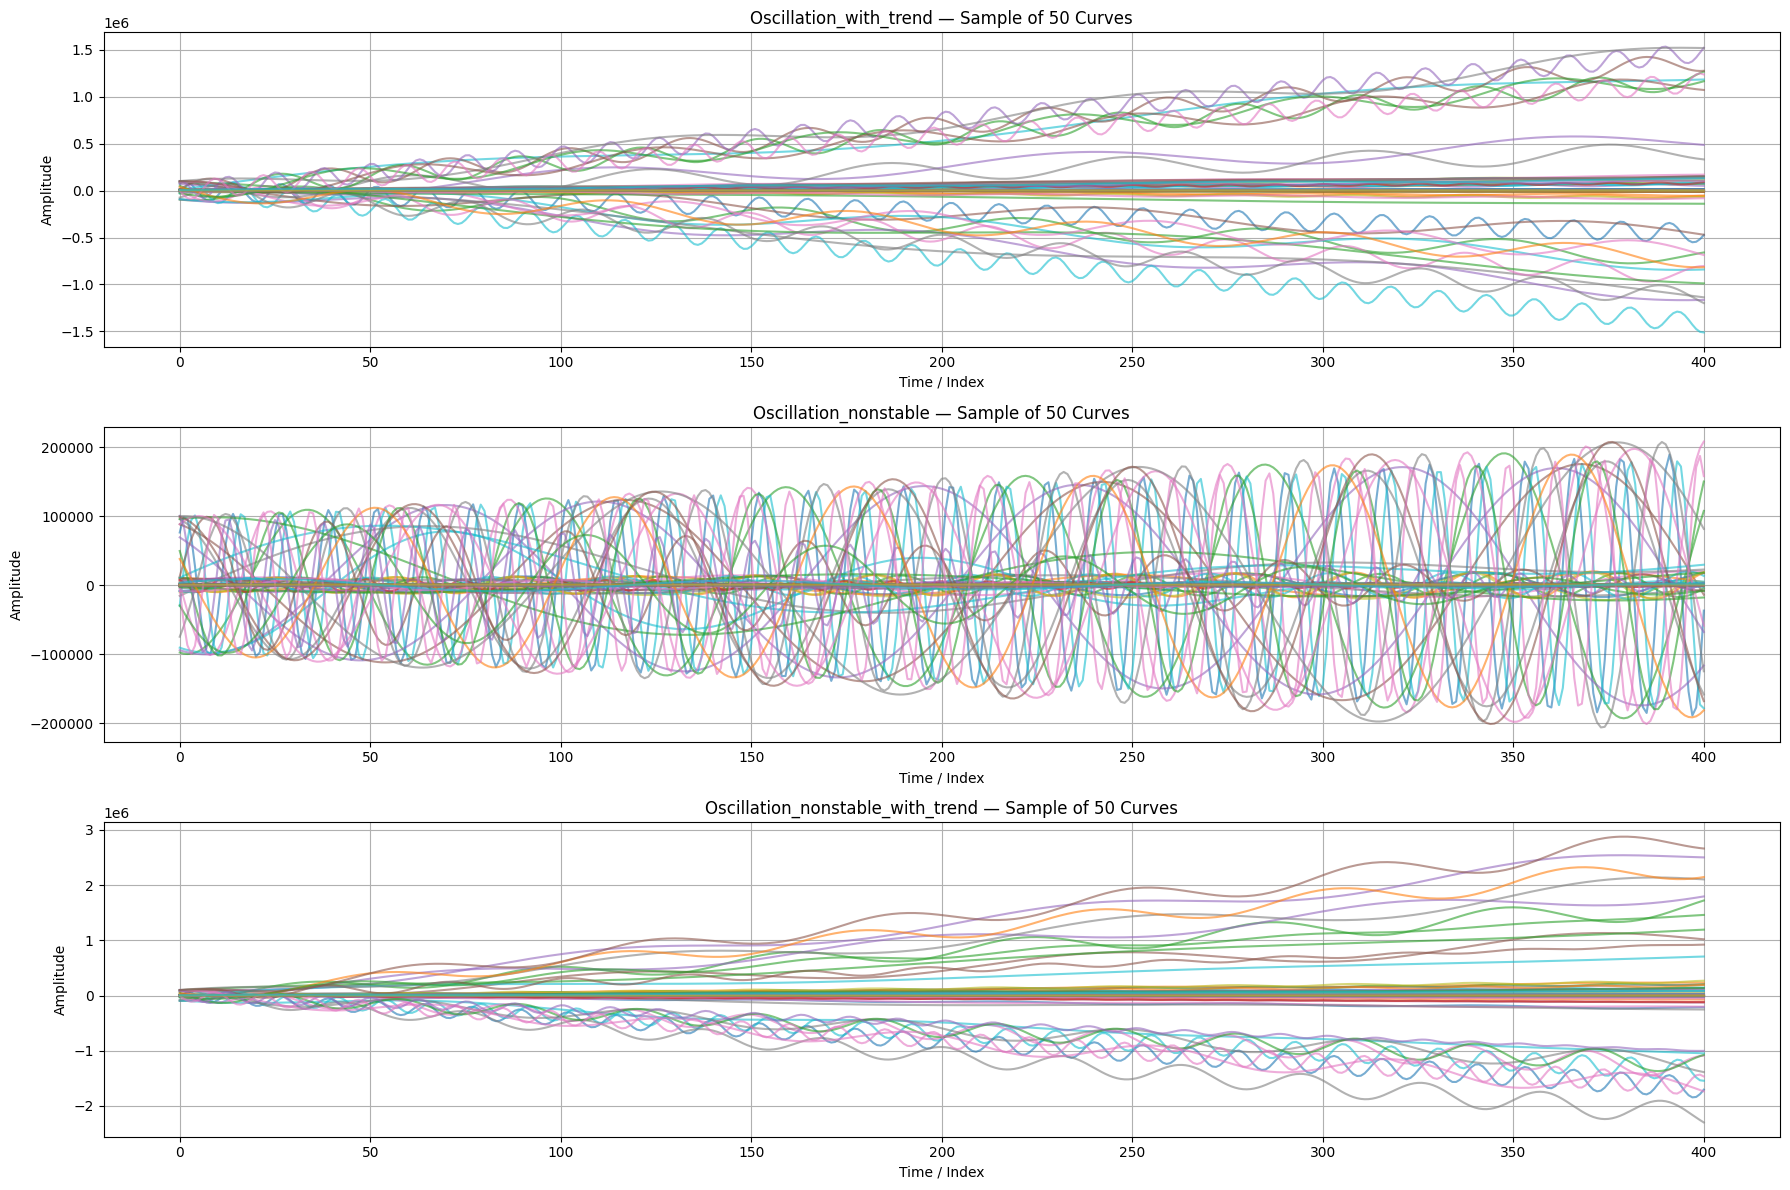

In [23]:
# Plot 50 curves from each oscillation variant
plt.figure(figsize=(18, 12))

classes = [
    ("Oscillation_with_trend", osc_with_trend),
    ("Oscillation_nonstable", osc_nonstable),
    ("Oscillation_nonstable_with_trend", osc_nonstable_with_trend),
]

for i, (title, df) in enumerate(classes, 1):
    plt.subplot(3, 1, i)
    for j in range(min(100, df.shape[0])):
        plt.plot(df.iloc[j][freq_col_arr].values, alpha=0.6)
    plt.title(f"{title} — Sample of 50 Curves")
    plt.xlabel("Time / Index")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.show()

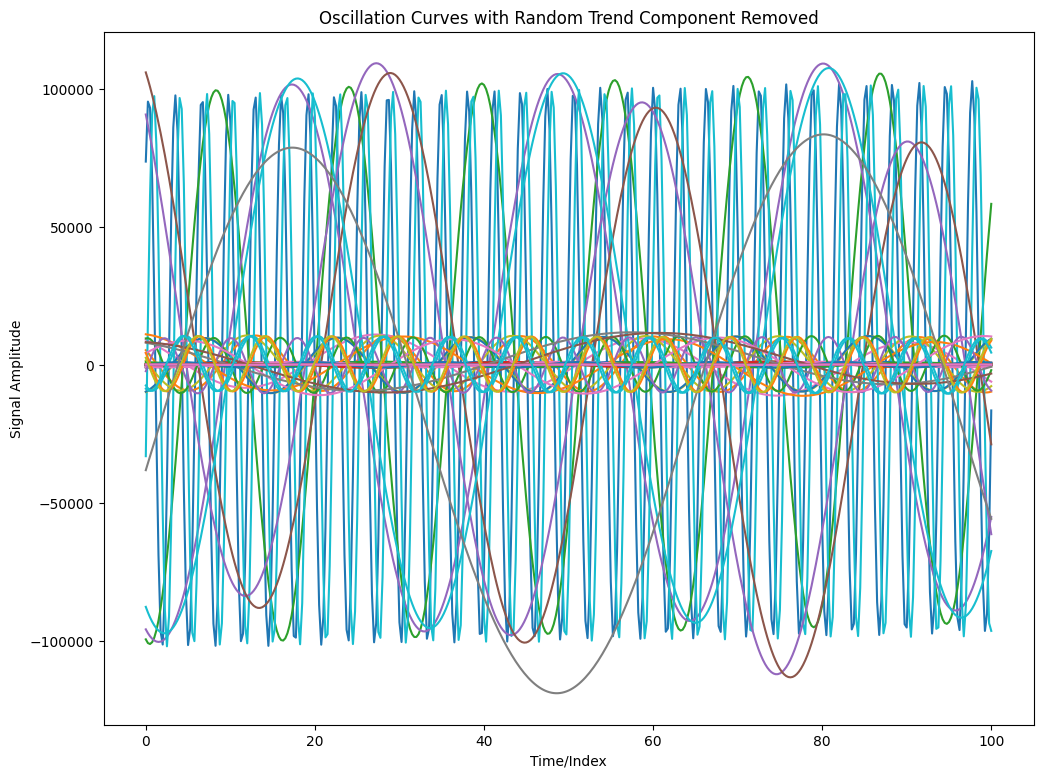

In [5]:
# Detrending Algorithm: processes all and fast, works the best
# Bu cell'i alttaki cell'deki damping-diverging detection testinde detrended data kullandığımız için ekledim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import detrend

# Assume full_df is your DataFrame
# The first column contains labels and the remaining columns are time/index values

# Extract numeric data (all columns except the first)
numeric_data = full_df.iloc[:, 1:]

# Apply detrending to each row (each curve), ensuring the shape remains correct
detrended_data = numeric_data.apply(lambda x: pd.Series(detrend(x), index=numeric_data.columns), axis=1)

# Re-attach the original labels to the detrended data
# Add the 'Label' column back to the detrended data, ensuring the structure matches full_df
full_df_detrended = pd.concat([full_df.iloc[:, [0]], detrended_data], axis=1)

# Filter for curves with the label "Oscillation"
oscillation_mask = full_df_detrended.iloc[:, 0] == "Oscillation"
oscillation_detrended = full_df_detrended.loc[oscillation_mask].iloc[:, 1:]  # numeric columns only

# Plot the first 10 "Oscillation" curves (or all if fewer than 10)
plt.figure(figsize=(12, 9))
for i in range(min(50, len(oscillation_detrended))):
    plt.plot(oscillation_detrended.iloc[i], label=f"Modified Oscillation {i+1}")

plt.title("Oscillation Curves with Random Trend Component Removed")
plt.xlabel("Time/Index")
plt.ylabel("Signal Amplitude")
plt.show()




Trend Detection Results:
Oscillation: {'Upward Trend': 397, 'Downward Trend': 404, 'No Trend': 799}

Damping/Diverging Results:
Oscillation: {'Dampening': 404, 'Diverging': 320, 'Stable': 684, 'Indeterminate': 192}


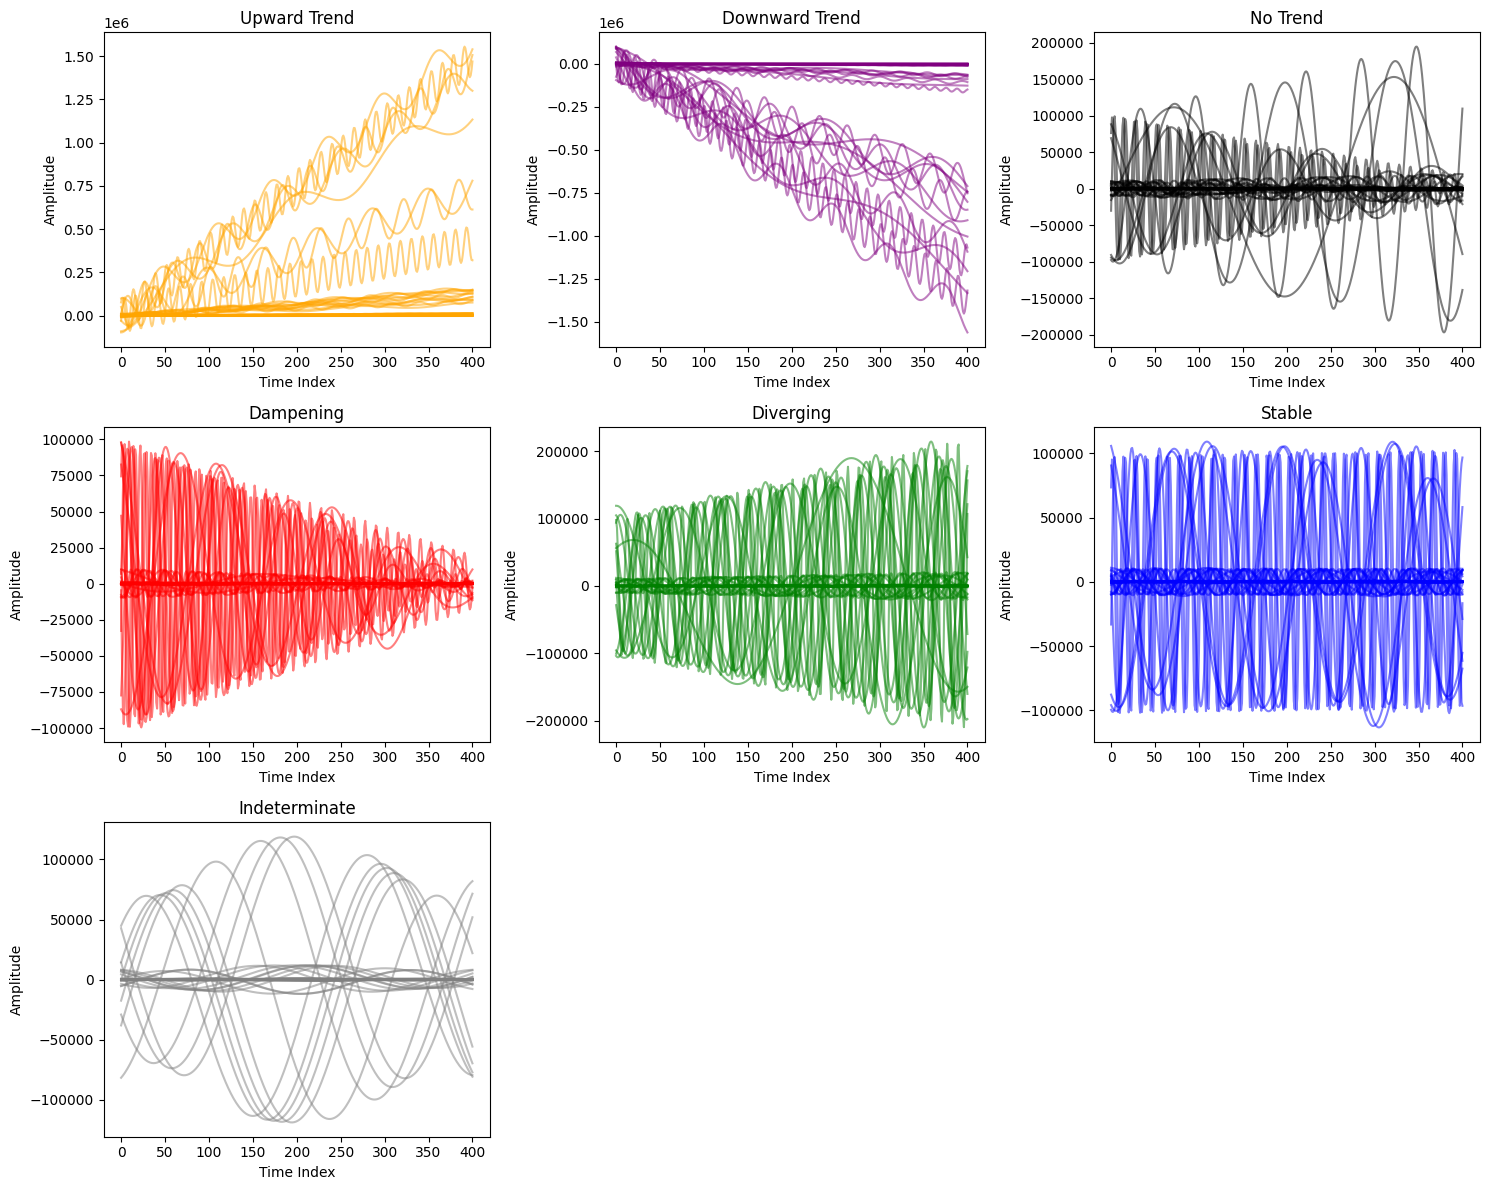

In [17]:
# Dampening / Diverging Detection Algorithm with Detrended Trend Detection via p value
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

osc_all_detrended = full_df_detrended[full_df_detrended["Label"].str.contains("Oscillation", na=False)]
osc_all = full_df[full_df["Label"].str.contains("Oscillation", na=False)]  # Make sure this exists

# Identify frequency columns (exclude "Label")
freq_col_arr = [col for col in osc_all.columns if col != "Label"]

# --- Detection Functions ---

def detect_trend_by_fit(y, p_threshold=1e-10):
    y = y.values.astype(float)
    x = np.array(freq_col_arr)  # Normalized time axis

    X = sm.add_constant(x)  # Add intercept
    model = sm.OLS(y, X).fit()

    p_value = model.pvalues[1]  # p-value of the slope

    if p_value < p_threshold:
        slope = model.params[1]
        return "Upward Trend" if slope > 0 else "Downward Trend"
    else:
        return "No Trend"

def detect_damping_or_diverging(y, threshold=0.001):
    # 1. Prepare signal
    y = y.values if hasattr(y, 'values') else np.asarray(y)
    x = np.arange(len(y)).reshape(-1, 1)

    # 2. Find peaks & valleys
    peaks, _   = find_peaks(y,      prominence=0.005)
    valleys, _ = find_peaks(-y,     prominence=0.005)

    if len(peaks) < 2 or len(valleys) < 2:
        return "Indeterminate"

    # 3. Fit lines: peaks
    x_peaks = peaks.reshape(-1, 1)
    y_peaks = y[peaks]
    model_p = LinearRegression().fit(x_peaks, y_peaks)
    slope_p = model_p.coef_[0]

    # 4. Fit lines: valleys
    x_valleys = valleys.reshape(-1, 1)
    y_valleys = y[valleys]
    model_v = LinearRegression().fit(x_valleys, y_valleys)
    slope_v = model_v.coef_[0]

    # 5. Decision rules
    # Diverging: peaks rising fast and valleys falling fast
    if slope_p > threshold and slope_v < -threshold:
        return "Diverging"
        
    # Dampening: peaks falling and valleys rising
    if slope_p < -threshold and slope_v > threshold:
        return "Dampening"

    # Otherwise amplitudes not changing much
    return "Stable"



# --- Classification and Stats ---

trend_stats = {}
damping_stats = {}

trend_up, trend_down, trend_none = [], [], []
dampening_curves, diverging_curves, stable_curves, indeterminate_curves = [], [], [], []

for i in range(osc_all.shape[0]):
    label = osc_all.iloc[i]["Label"]
    original_curve = osc_all.iloc[i][freq_col_arr].astype(float)
    detrended_curve = osc_all_detrended.iloc[i][freq_col_arr].astype(float)

    if label not in trend_stats:
        trend_stats[label] = {"Upward Trend": 0, "Downward Trend": 0, "No Trend": 0}
    if label not in damping_stats:
        damping_stats[label] = {"Dampening": 0, "Diverging": 0, "Stable": 0, "Indeterminate": 0}

    # Trend detection using detrending
    trend_result = detect_trend_by_fit(original_curve)
    trend_stats[label][trend_result] += 1
    if trend_result == "Upward Trend":
        trend_up.append(original_curve)
    elif trend_result == "Downward Trend":
        trend_down.append(original_curve)
    else:
        trend_none.append(original_curve)

    # Damping/diverging detection
    damping_result = detect_damping_or_diverging(detrended_curve)
    damping_stats[label][damping_result] += 1
    if damping_result == "Dampening":
        dampening_curves.append(detrended_curve)
    elif damping_result == "Diverging":
        diverging_curves.append(detrended_curve)
    elif damping_result == "Stable":
        stable_curves.append(detrended_curve)
    else:
        indeterminate_curves.append(detrended_curve)

# --- Reporting ---

print("Trend Detection Results:")
for label, counts in trend_stats.items():
    print(f"{label}: {counts}")

print("\nDamping/Diverging Results:")
for label, counts in damping_stats.items():
    print(f"{label}: {counts}")

# --- Plotting ---

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
plot_sets = [
    (trend_up, "Upward Trend", 'orange'),
    (trend_down, "Downward Trend", 'purple'),
    (trend_none, "No Trend", 'black'),
    (dampening_curves, "Dampening", 'red'),
    (diverging_curves, "Diverging", 'green'),
    (stable_curves, "Stable", 'blue'),
    (indeterminate_curves, "Indeterminate", 'gray')
]

for idx, (curves, title, color) in enumerate(plot_sets):
    ax = axes[idx // 3, idx % 3]
    for curve in curves[:50]:
        ax.plot(curve.to_numpy(), color=color, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Amplitude")

# Hide unused subplots if any
for j in range(len(plot_sets), 9):
    fig.delaxes(axes[j // 3, j % 3])

plt.tight_layout()
plt.show()


,mean_val,max_val,min_val
Label,,,
Oscillation,11.465,33,2
GR2D2,1.000,1,1
GR2D3,1.000,1,1
NEXGR,1.000,1,1
PEXGR,1.000,1,1
SSHGR,1.000,1,1


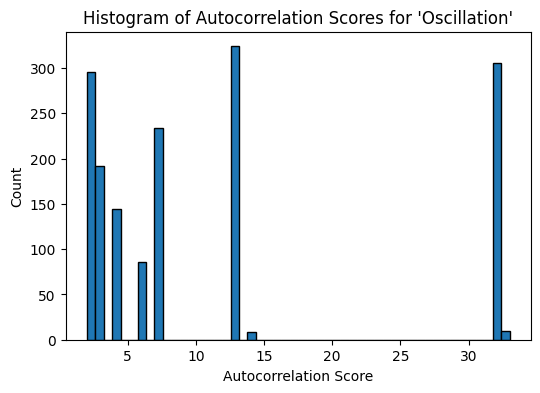

<Axes: xlabel='Label', ylabel='peak count'>

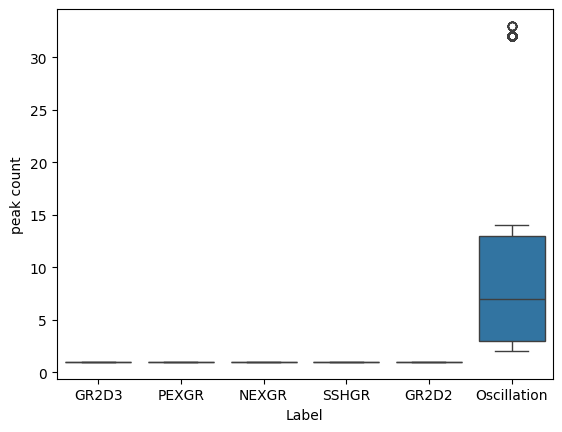

In [7]:
# F1: Total number of peaks. Works after detrending whole dataset
number_of_peaks = []
osc_test = full_df_detrended[full_df_detrended["Label"]!="LNRGR"].copy()
for _, curve in osc_test.drop(columns=["Label"]).iterrows():
    # Find peaks
    peaks, _ = find_peaks(curve, prominence=0.01)
    # Find valleys (by inverting the signal)
    valleys, _ = find_peaks(-curve, prominence=0.01)
    
    # Take the maximum count between peaks and valleys
    number_of_peaks.append(max(len(peaks), len(valleys)))

osc_test["peak count"] = number_of_peaks



import matplotlib.pyplot as plt

# 1. Compute grouped statistics
osc_type_ser = osc_test.groupby("Label").agg(
    mean_val = ("peak count", "mean"),
    max_val = ("peak count", "max"),
    min_val = ("peak count", "min")
)
osc_type_ser = osc_type_ser.sort_values("mean_val", ascending=False)
display(osc_type_ser)

# 2. Filter the DataFrame for the "Oscillation" label
oscillation_scores = osc_test.loc[osc_test["Label"] == "Oscillation", "peak count"]

# 3. Plot a histogram with 10 bins
plt.figure(figsize=(6, 4))
plt.hist(oscillation_scores, bins=50, edgecolor='black')
plt.title("Histogram of Autocorrelation Scores for 'Oscillation'")
plt.xlabel("Autocorrelation Score")
plt.ylabel("Count")
plt.show()

sns.boxplot(osc_test, x="Label", y="peak count")


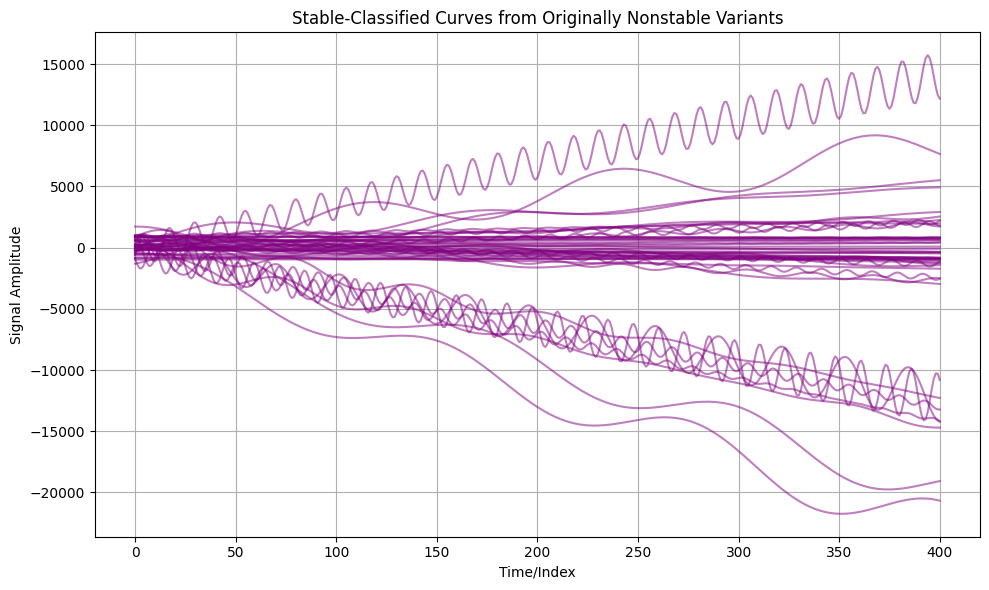

In [31]:
# Plot only STABLE curves that were originally nonstable variants
# Get row indices of stable-classified curves with the specified original labels
stable_indices = []

for i in range(osc_all.shape[0]):
    if max(osc_all.iloc[i][freq_col_arr]) - min(osc_all.iloc[i][freq_col_arr]) < 25000: 
        label = osc_all.iloc[i]["Label"]
        if label in ["Oscillation_nonstable", "Oscillation_nonstable_with_trend"]:
            curve = osc_all.iloc[i][freq_col_arr]
            result = detect_damping_or_diverging(curve)
            if result == "Stable":
                stable_indices.append(i)

# Extract those curves
stable_nonstable_curves = [osc_all.iloc[i][freq_col_arr] for i in stable_indices]

# Plot them
plt.figure(figsize=(10, 6))
for curve in stable_nonstable_curves[:50]:  # limit to first 50 for clarity
    plt.plot(curve.to_numpy(), color='purple', alpha=0.5)

plt.title('Stable-Classified Curves from Originally Nonstable Variants')
plt.xlabel('Time/Index')
plt.ylabel('Signal Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()


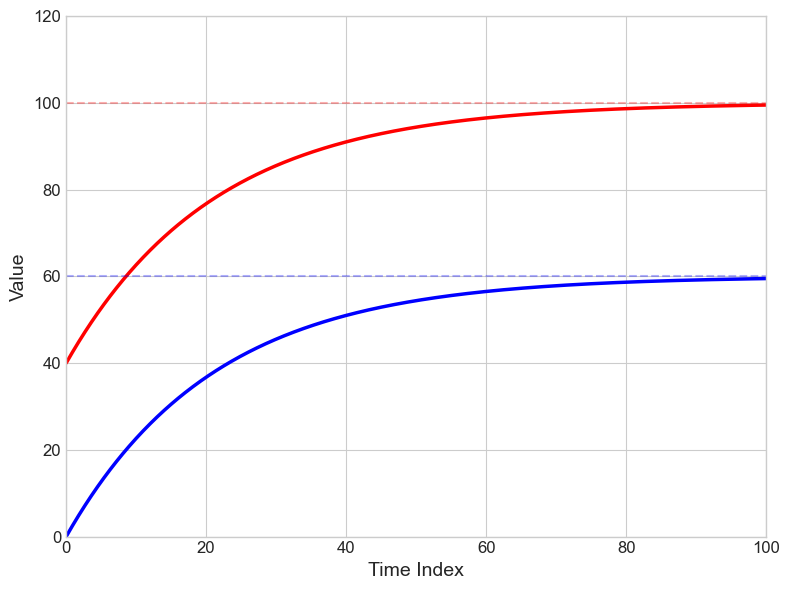

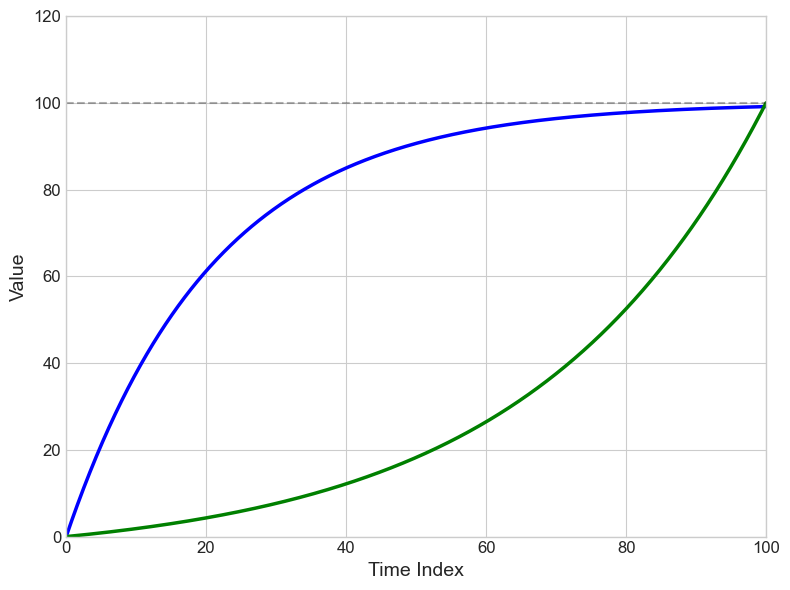

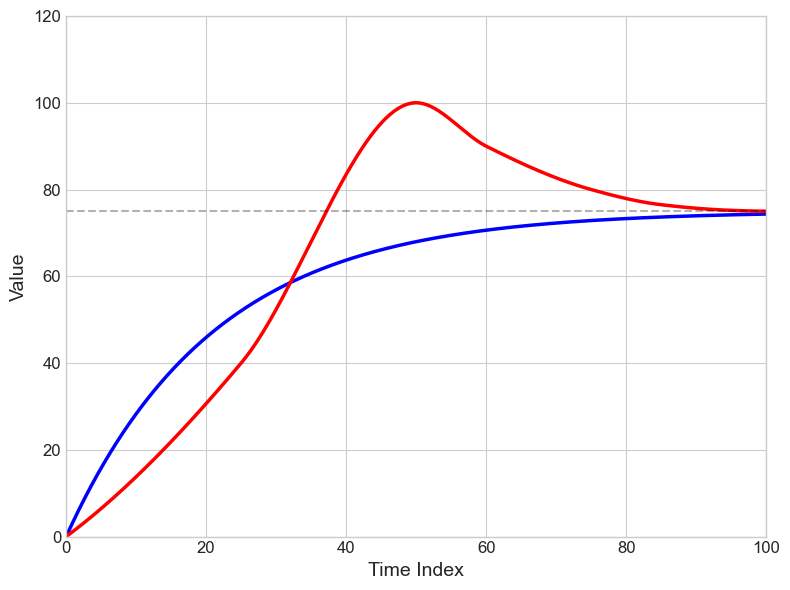

In [76]:
# 3 Graphs for the UI
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy import optimize
import matplotlib as mpl

# Set figure style
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['figure.figsize'] = [8, 8]
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

# Custom logarithmic function that reaches target value at x=95
def log_curve(x, start_val, end_val):
    # Scale factor to make curve reach ~99% of final value at x=95
    k = 4.5 / 95
    return start_val + (end_val - start_val) * (1 - np.exp(-k * x))

# Time indexes from 0 to 100
x = np.linspace(0, 100, 1000)

# Plot 1: Two logarithmic curves with offsets
plt.figure(figsize=(8, 6))

# First curve: 0 to 75
y1_log1 = log_curve(x, 0, 60)
# Second curve: First curve + 25 offset
y1_log2 = log_curve(x, 40, 100)

plt.plot(x, y1_log1, 'b-', linewidth=2.5)
plt.plot(x, y1_log2, 'r-', linewidth=2.5)
plt.axhline(y=60, color='b', linestyle='--', alpha=0.3)
plt.axhline(y=100, color='r', linestyle='--', alpha=0.3)
plt.xlabel('Time Index')
plt.ylabel('Value')
plt.xlim(0, 100)
plt.ylim(0, 120)
plt.tight_layout()
plt.savefig('plot1_two_logarithmic_curves.png')

# Plot 2: One logarithmic and one exponential curve
plt.figure(figsize=(8, 6))

# Custom exponential function that starts at 0 and ends at 100
def exp_curve(x, start_val, end_val):
    # Use a function that rises slowly at first then accelerates
    max_x = 100
    return start_val + (end_val - start_val) * (np.exp(3 * x / max_x) - 1) / (np.exp(3) - 1)

# Logarithmic curve: 0 to 100
y2_log = log_curve(x, 0, 100)
# Exponential curve: 0 to 100
y2_exp = exp_curve(x, 0, 100)

plt.plot(x, y2_log, 'b-', linewidth=2.5)
plt.plot(x, y2_exp, 'g-', linewidth=2.5)
plt.axhline(y=100, color='k', linestyle='--', alpha=0.3)
plt.xlabel('Time Index')
plt.ylabel('Value')
plt.xlim(0, 100)
plt.ylim(0, 120)
plt.tight_layout()
plt.savefig('plot2_logarithmic_exponential_curves.png')

# Plot 3: One logarithmic curve and one boom-and-bust curve
plt.figure(figsize=(8, 6))

# Logarithmic curve: 0 to 75
y3_log = log_curve(x, 0, 75)

# Create boom-and-bust curve with specific shape requirements
# Define key points for the boom-and-bust curve
# Format: (x, y)
key_points = [
    (0, 0, 0.1),           # Start point
    (25, 40, 1.5),         # Inflection point during boom
    (50, 100, 0),          # Peak
    (60, 90, -0.5),        # Inflection point during bust (smoother transition)
    (75, 80, -0.3),        # Additional point to make decline more gradual
    (85, 76.5, -0.1),      # Additional point to flatten the tail
    (95, 75.2, -0.01),     # Near stabilization with flatter slope
    (100, 75, 0)           # End point
]

# Extract x, y coordinates from key points
x_control = np.array([p[0] for p in key_points])
y_control = np.array([p[1] for p in key_points])
dydx = np.array([p[2] for p in key_points])

# Create a piecewise cubic Hermite interpolator
boom_bust_interp = PchipInterpolator(x_control, y_control)

# Generate the boom-bust curve
y3_boombust = boom_bust_interp(x)

# Generate the boom-bust curve
y3_boombust = boom_bust_interp(x)

plt.plot(x, y3_log, 'b-', linewidth=2.5)
plt.plot(x, y3_boombust, 'r-', linewidth=2.5)
plt.axhline(y=75, color='k', linestyle='--', alpha=0.3)
plt.xlabel('Time Index')
plt.ylabel('Value')
plt.xlim(0, 100)
plt.ylim(0, 120)
plt.tight_layout()
plt.savefig('plot3_logarithmic_boom_bust_curves.png')